In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.metrics import f1_score
from sklearn.base import BaseEstimator, ClassifierMixin
from imblearn.over_sampling import SMOTE
from collections import Counter


In [43]:
testing = pd.read_csv("dataset/UNSW_NB15_training-set.csv")

training = pd.read_csv("dataset/UNSW_NB15_testing-set.csv")
print(f"training dimensions: {training.shape}\n testing dimensions: {testing.shape}")

training.head()

training dimensions: (175341, 45)
 testing dimensions: (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [ ]:
training = training.drop(axis = 1, columns=['id'])
testing = testing.drop(axis = 1,columns = ['id'])

training = training.dropna(subset=['attack_cat'])
testing = testing.dropna(subset=['attack_cat'])


X_train, X_test = training.drop(axis = 1,columns=['attack_cat', 'label']), testing.drop(axis = 1,columns=['attack_cat', 'label'])
y_train, y_test = training['attack_cat'], testing['attack_cat']

categorical_features = list(training.select_dtypes(include=['object']).columns)
categorical_features.remove("attack_cat") # this is different since it is our multi-class label

print(f"Categorical Features: {categorical_features}")

for col in categorical_features:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')
    X_test[col] = X_test[col].cat.set_categories(X_train[col].cat.categories)

X_train_reduced, X_test_reduced = X_train, X_test

le = LabelEncoder()

y_train_final = le.fit_transform(y_train)
y_test_final = le.transform(y_test)





Categorical Features: ['proto', 'service', 'state']


In [41]:
class_counts = Counter(y_train_final)

for i, count in sorted(class_counts.items()):
    print(f"Class {le.inverse_transform([i])[0]}: {count} samples")

Class Analysis: 2000 samples
Class Backdoor: 1746 samples
Class DoS: 12264 samples
Class Exploits: 33393 samples
Class Fuzzers: 18184 samples
Class Generic: 40000 samples
Class Normal: 56000 samples
Class Reconnaissance: 10491 samples
Class Shellcode: 1133 samples
Class Worms: 130 samples


In [26]:
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_encode = X_train_reduced.copy()
X_test_encode = X_test_reduced.copy()

X_train_encode[categorical_features] = oe.fit_transform(X_train_reduced[categorical_features])
X_test_encode[categorical_features] = oe.transform(X_test_reduced[categorical_features])

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encode)
X_test_scaled = scaler.transform(X_test_encode)

In [27]:
print(list(enumerate(le.classes_)))

[(0, 'Analysis'), (1, 'Backdoor'), (2, 'DoS'), (3, 'Exploits'), (4, 'Fuzzers'), (5, 'Generic'), (6, 'Normal'), (7, 'Reconnaissance'), (8, 'Shellcode'), (9, 'Worms')]


In [54]:


sampling_strategy = {
    0: 34000,  # Analysis
    1: 34000,  # Backdoor
    2: 34000,  # DoS
    3: 34000,  # Exploits
    4: 30000,  # Fuzzers
    5: 40000,  # Generic
    6: 56000,  # Normal
    7: 34000,  # Reconnaissance
    8: 5000,  # Shellcode  ← don't over-generate from 130 samples
    9: 3000,  # Worms
}


smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_final)

print(f"before smote: {X_train_scaled.shape}")
print(f"after smote: {X_train_smote.shape}")


before smote: (175341, 42)
after smote: (304000, 42)


In [47]:
class_counts = Counter(y_train_smote)
class_names = le.inverse_transform(list(class_counts.keys()))

for i, count in enumerate(class_counts.values()):
    print(f"Class {class_names[i]}: {count} samples")


Class Normal: 56000 samples
Class Backdoor: 8000 samples
Class Analysis: 10000 samples
Class Fuzzers: 30000 samples
Class Shellcode: 4000 samples
Class Reconnaissance: 20000 samples
Class Exploits: 56000 samples
Class DoS: 20000 samples
Class Worms: 500 samples
Class Generic: 56000 samples


In [56]:
sample_weights = compute_sample_weight(class_weight = 'balanced', y = y_train_smote)

[0]	validation_0-mlogloss:2.00662
[1]	validation_0-mlogloss:1.81906
[2]	validation_0-mlogloss:1.68248
[3]	validation_0-mlogloss:1.57402
[4]	validation_0-mlogloss:1.48374
[5]	validation_0-mlogloss:1.40831
[6]	validation_0-mlogloss:1.34255
[7]	validation_0-mlogloss:1.28549
[8]	validation_0-mlogloss:1.23595
[9]	validation_0-mlogloss:1.19255
[10]	validation_0-mlogloss:1.15424
[11]	validation_0-mlogloss:1.12045
[12]	validation_0-mlogloss:1.09013
[13]	validation_0-mlogloss:1.06344
[14]	validation_0-mlogloss:1.03976
[15]	validation_0-mlogloss:1.01832
[16]	validation_0-mlogloss:0.99970
[17]	validation_0-mlogloss:0.98130
[18]	validation_0-mlogloss:0.96487
[19]	validation_0-mlogloss:0.95004
[20]	validation_0-mlogloss:0.93732
[21]	validation_0-mlogloss:0.92573
[22]	validation_0-mlogloss:0.91403
[23]	validation_0-mlogloss:0.90357
[24]	validation_0-mlogloss:0.89492
[25]	validation_0-mlogloss:0.88618
[26]	validation_0-mlogloss:0.87863
[27]	validation_0-mlogloss:0.87174
[28]	validation_0-mlogloss:0.8

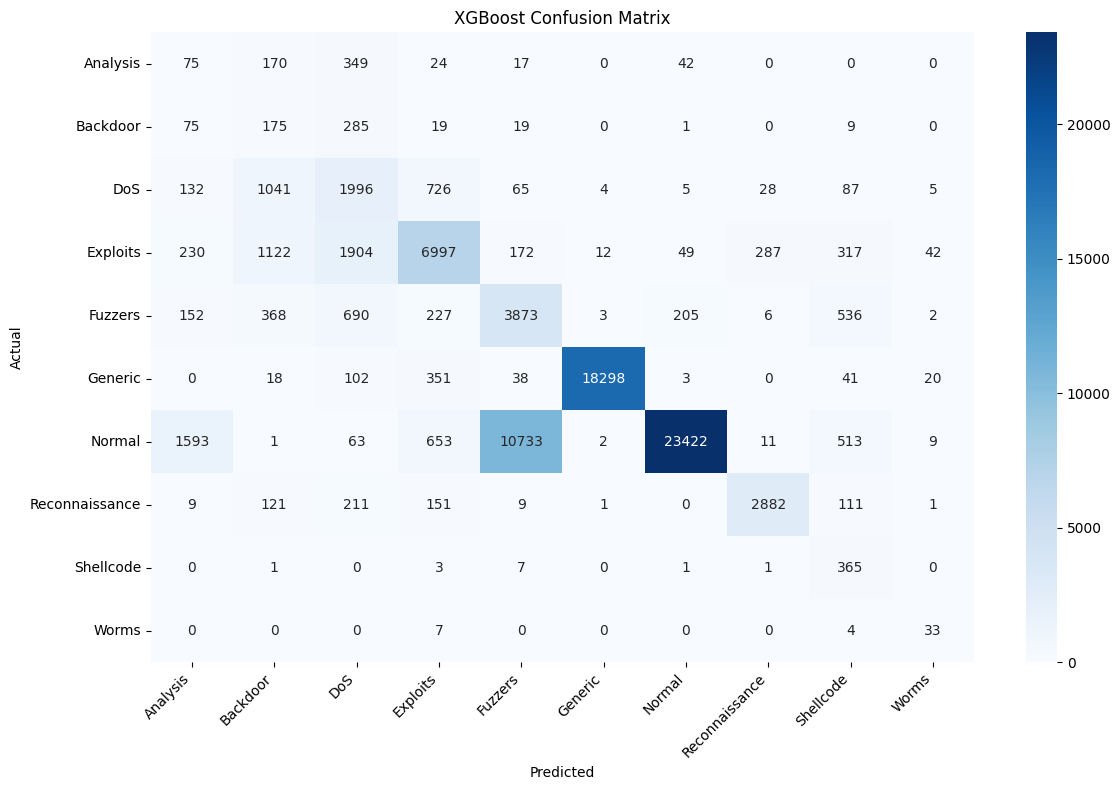

In [57]:
xgb = XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.1,
    random_state = 42,
    n_jobs = -1,
    eval_metric = 'mlogloss',
    objective = 'multi:softprob',
    num_class = len(le.classes_),
    early_stopping_rounds = 20,
    gamma = 1,
    reg_alpha = 0.1,
    reg_lambda = 1.5
)

xgb.fit(X_train_smote, y_train_smote, eval_set = [(X_test_scaled, y_test_final)], sample_weight = sample_weights)
y_predict = xgb.predict(X_test_scaled)

print(classification_report(y_test_final, y_predict, target_names=le.classes_))

cm = confusion_matrix(y_test_final, y_predict)

plt.figure(figsize=(12, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [49]:
# See exactly where Analysis and Backdoor are being misclassified
cm = confusion_matrix(y_test_final, y_predict)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

print("Analysis predicted as:")
print(cm_df.loc['Analysis'].sort_values(ascending=False))
print("\nBackdoor predicted as:")
print(cm_df.loc['Backdoor'].sort_values(ascending=False))
print("\nDoS predicted as:")
print(cm_df.loc['DoS'].sort_values(ascending=False))

Analysis predicted as:
Exploits          371
Analysis          117
Backdoor           73
DoS                53
Normal             52
Fuzzers            11
Generic             0
Reconnaissance      0
Shellcode           0
Worms               0
Name: Analysis, dtype: int64

Backdoor predicted as:
Exploits          302
Analysis          118
Backdoor           80
DoS                55
Fuzzers            13
Shellcode           9
Generic             6
Normal              0
Reconnaissance      0
Worms               0
Name: Backdoor, dtype: int64

DoS predicted as:
Exploits          2616
Backdoor           674
DoS                442
Analysis           157
Shellcode           67
Fuzzers             64
Reconnaissance      30
Generic             25
Normal              14
Worms                0
Name: DoS, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

# Combine and re-split randomly like the paper did
full_data = pd.concat([training, testing], ignore_index=True)

X = full_data.drop(columns=['attack_cat', 'label'])
y = full_data['attack_cat']

# Encode categoricals
categorical_features = list(X.select_dtypes(include=['object']).columns)
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[categorical_features] = oe.fit_transform(X[categorical_features])

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# SMOTE
smote = SMOTE(k_neighbors=5, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# PCA with fixed 20 components like the paper
pca = PCA(n_components=20)
X_train_pca = pca.fit_transform(X_train_smote)
X_test_pca  = pca.transform(X_test_scaled)

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    objective='multi:softmax',
    num_class=len(le.classes_),
    early_stopping_rounds=20
)

xgb_model.fit(
    X_train_pca, y_train_smote,
    eval_set=[(X_test_pca, y_test)],
)

y_pred = xgb_model.predict(X_test_pca)
macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"Macro F1: {macro_f1:.4f}")
print(classification_report(y_test, y_pred, target_names=le.classes_))

[0]	validation_0-mlogloss:2.15748
[1]	validation_0-mlogloss:2.04201
[2]	validation_0-mlogloss:1.94477
[3]	validation_0-mlogloss:1.86120
[4]	validation_0-mlogloss:1.78764
[5]	validation_0-mlogloss:1.72286
[6]	validation_0-mlogloss:1.66481
[7]	validation_0-mlogloss:1.61189
[8]	validation_0-mlogloss:1.56254
[9]	validation_0-mlogloss:1.51793
[10]	validation_0-mlogloss:1.47612
[11]	validation_0-mlogloss:1.43819
[12]	validation_0-mlogloss:1.40243
[13]	validation_0-mlogloss:1.36877
[14]	validation_0-mlogloss:1.33711
[15]	validation_0-mlogloss:1.30758
[16]	validation_0-mlogloss:1.27960
[17]	validation_0-mlogloss:1.25339
[18]	validation_0-mlogloss:1.22858
[19]	validation_0-mlogloss:1.20595
[20]	validation_0-mlogloss:1.18421
[21]	validation_0-mlogloss:1.16403
[22]	validation_0-mlogloss:1.14482
[23]	validation_0-mlogloss:1.12630
[24]	validation_0-mlogloss:1.10835
[25]	validation_0-mlogloss:1.09185
[26]	validation_0-mlogloss:1.07576
[27]	validation_0-mlogloss:1.06043
[28]	validation_0-mlogloss:1.0

In [ ]:
from sklearn.model_selection import train_test_split

# Use random 70/30 split
full_data = pd.concat([training, testing], ignore_index=True)
X_full = full_data.drop(columns=['attack_cat', 'label'])
y_full = le.fit_transform(full_data['attack_cat'])

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.3, random_state=42, stratify=y_full
)

# Encode + Scale
X_train_enc = X_train.copy()
X_test_enc  = X_test.copy()
X_train_enc[categorical_features] = oe.fit_transform(X_train[categorical_features])
X_test_enc[categorical_features]  = oe.transform(X_test[categorical_features])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled  = scaler.transform(X_test_enc)

# Only SMOTE the classes with enough real samples
# Skip Analysis(0), Backdoor(1), Worms(9) — too few real samples
print(list(enumerate(le.classes_)))  # confirm indices first

sampling_strategy = {
    2: 20000,   # DoS        — currently 11447
    3: 35000,   # Exploits   — currently 31167
    4: 25000,   # Fuzzers    — currently 16972
    7: 15000,   # Reconnaissance — currently 9791
    8: 4000,    # Shellcode  — currently 1058
}



smote = SMOTE(sampling_strategy=sampling_strategy, k_neighbors=5, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Manually boost weights for the skipped minority classes
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_smote)

xgb_model = XGBClassifier(
    n_estimators=1000,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    objective='multi:softmax',
    num_class=len(le.classes_),
    early_stopping_rounds=30
)

xgb_model.fit(
    X_train_smote, y_train_smote,
    sample_weight=sample_weights,
    eval_set=[(X_test_scaled, y_test)],
)

y_pred = xgb_model.predict(X_test_scaled)
macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"Macro F1: {macro_f1:.4f}")
print(classification_report(y_test, y_pred, target_names=le.classes_))

[(0, 'Analysis'), (1, 'Backdoor'), (2, 'DoS'), (3, 'Exploits'), (4, 'Fuzzers'), (5, 'Generic'), (6, 'Normal'), (7, 'Reconnaissance'), (8, 'Shellcode'), (9, 'Worms')]
[0]	validation_0-mlogloss:2.12536
[1]	validation_0-mlogloss:1.98471
[2]	validation_0-mlogloss:1.87153
[3]	validation_0-mlogloss:1.77398
[4]	validation_0-mlogloss:1.68374
[5]	validation_0-mlogloss:1.60539
[6]	validation_0-mlogloss:1.53369
[7]	validation_0-mlogloss:1.46884
[8]	validation_0-mlogloss:1.40902
[9]	validation_0-mlogloss:1.35437
[10]	validation_0-mlogloss:1.30408
[11]	validation_0-mlogloss:1.25701
[12]	validation_0-mlogloss:1.21432
[13]	validation_0-mlogloss:1.17436
[14]	validation_0-mlogloss:1.13826
[15]	validation_0-mlogloss:1.10331
[16]	validation_0-mlogloss:1.07023
[17]	validation_0-mlogloss:1.03885
[18]	validation_0-mlogloss:1.00987
[19]	validation_0-mlogloss:0.98376
[20]	validation_0-mlogloss:0.95770
[21]	validation_0-mlogloss:0.93354
[22]	validation_0-mlogloss:0.91039
[23]	validation_0-mlogloss:0.88831
[24]

In [68]:
sampling_strategy_new = {
    0: 5000,    # Analysis    — currently 1874, small boost
    1: 5000,    # Backdoor    — currently 1630, small boost
    2: 20000,   # DoS
    3: 35000,   # Exploits
    4: 25000,   # Fuzzers
    7: 15000,   # Reconnaissance
    8: 4000,    # Shellcode
}

sampling_strategy_new2 = {
    0: 10000,   # Analysis    — currently at 5000, double it
    1: 10000,   # Backdoor    — currently at 5000, double it
    2: 20000,   # DoS         — keep
    3: 35000,   # Exploits    — keep
    4: 25000,   # Fuzzers     — keep
    7: 15000,   # Reconnaissance — keep
    8: 4000,    # Shellcode   — keep
}

In [ ]:
smote = SMOTE(sampling_strategy=sampling_strategy_new2, k_neighbors=5, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Manually boost weights for the skipped minority classes
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_smote)

xgb_model = XGBClassifier(
    n_estimators=1000,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    objective='multi:softmax',
    num_class=len(le.classes_),
    early_stopping_rounds=30
)

xgb_model.fit(
    X_train_smote, y_train_smote,
    sample_weight=sample_weights,
    eval_set=[(X_test_scaled, y_test)],
)

y_pred = xgb_model.predict(X_test_scaled)
macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"Macro F1: {macro_f1:.4f}")
print(classification_report(y_test, y_pred, target_names=le.classes_))

[0]	validation_0-mlogloss:2.12495
[1]	validation_0-mlogloss:1.98347
[2]	validation_0-mlogloss:1.86929
[3]	validation_0-mlogloss:1.77111
[4]	validation_0-mlogloss:1.68067
[5]	validation_0-mlogloss:1.60213
[6]	validation_0-mlogloss:1.53029
[7]	validation_0-mlogloss:1.46525
[8]	validation_0-mlogloss:1.40540
[9]	validation_0-mlogloss:1.35082
[10]	validation_0-mlogloss:1.30031
[11]	validation_0-mlogloss:1.25314
[12]	validation_0-mlogloss:1.21000
[13]	validation_0-mlogloss:1.16953
[14]	validation_0-mlogloss:1.13318
[15]	validation_0-mlogloss:1.09809
[16]	validation_0-mlogloss:1.06456
[17]	validation_0-mlogloss:1.03320
[18]	validation_0-mlogloss:1.00411
[19]	validation_0-mlogloss:0.97743
[20]	validation_0-mlogloss:0.95124
[21]	validation_0-mlogloss:0.92677
[22]	validation_0-mlogloss:0.90355
[23]	validation_0-mlogloss:0.88122
[24]	validation_0-mlogloss:0.86008
[25]	validation_0-mlogloss:0.84074
[26]	validation_0-mlogloss:0.82200
[27]	validation_0-mlogloss:0.80427
[28]	validation_0-mlogloss:0.7

In [69]:
smote = SMOTE(sampling_strategy=sampling_strategy_new2, k_neighbors=5, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Manually boost weights for the skipped minority classes
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_smote)

xgb_model = XGBClassifier(
    n_estimators=1000,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    objective='multi:softmax',
    num_class=len(le.classes_),
    early_stopping_rounds=30
)

xgb_model.fit(
    X_train_smote, y_train_smote,
    sample_weight=sample_weights,
    eval_set=[(X_test_scaled, y_test)],
)

y_pred = xgb_model.predict(X_test_scaled)
macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"Macro F1: {macro_f1:.4f}")
print(classification_report(y_test, y_pred, target_names=le.classes_))

[0]	validation_0-mlogloss:2.12456
[1]	validation_0-mlogloss:1.98335
[2]	validation_0-mlogloss:1.86877
[3]	validation_0-mlogloss:1.77027
[4]	validation_0-mlogloss:1.68000
[5]	validation_0-mlogloss:1.60150
[6]	validation_0-mlogloss:1.52949
[7]	validation_0-mlogloss:1.46447
[8]	validation_0-mlogloss:1.40395
[9]	validation_0-mlogloss:1.34916
[10]	validation_0-mlogloss:1.29850
[11]	validation_0-mlogloss:1.25121
[12]	validation_0-mlogloss:1.20767
[13]	validation_0-mlogloss:1.16726
[14]	validation_0-mlogloss:1.13082
[15]	validation_0-mlogloss:1.09560
[16]	validation_0-mlogloss:1.06214
[17]	validation_0-mlogloss:1.03070
[18]	validation_0-mlogloss:1.00160
[19]	validation_0-mlogloss:0.97484
[20]	validation_0-mlogloss:0.94828
[21]	validation_0-mlogloss:0.92380
[22]	validation_0-mlogloss:0.90052
[23]	validation_0-mlogloss:0.87811
[24]	validation_0-mlogloss:0.85679
[25]	validation_0-mlogloss:0.83733
[26]	validation_0-mlogloss:0.81822
[27]	validation_0-mlogloss:0.80041
[28]	validation_0-mlogloss:0.7